In [1]:
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import calendar
np.random.seed(42)

In [2]:
ORDER_PATH = "../data/huggingface/nhd_id_stream_order_permanence.csv"
OBS_PATH = "../data/sciencebase/obs.csv"
stream_order = pd.read_csv(ORDER_PATH)
obs_df = pd.read_csv(OBS_PATH)

# Canonical flagship RGCN: q65 temporal split (cutoff 2020-09-10), strict
# forecast-tail masking (obs + drivers frozen at day t), no lag-7 features,
# 35 inputs incl. 17 statics. Produced by the rgcn/pipeline stages with
# RGCN_CONFIG=rgcn/flagship/config_q65.yml (see the repo README for the exact
# command sequence; seeds 43/44 use config_q65_s43/_s44.yml).
PRED_DIR = "../data/retrain/flagship/predictions_flag_q65"
DAY_1_PATH = f"{PRED_DIR}/train_val_predictions_day1.csv"
DAY_2_PATH = f"{PRED_DIR}/train_val_predictions_day2.csv"
DAY_3_PATH = f"{PRED_DIR}/train_val_predictions_day3.csv"
WINDOW_SPLIT_PATH = "../data/retrain/flagship/window_split_map_flagq65.csv"

# Daily-grid (stride-1) day-3 export over the val period — used by the annual
# dry-day (copula) section below. Produced by:
#   RGCN_CONFIG=rgcn/flagship/config_q65.yml uv run python -m \
#     rgcn.pipeline.export_predictions --eval-stride 1 \
#     --day3-range "2020-09-11:2020-12-31"
STRIDE1_DAY3_PATH = ("../data/retrain/flagship/predictions_flag_q65_stride1"
                     "/train_val_predictions_day3.csv")

day_1_df = pd.read_csv(DAY_1_PATH)
day_2_df = pd.read_csv(DAY_2_PATH)
day_3_df = pd.read_csv(DAY_3_PATH)

# Load window-based split and apply to all dfs
split_map = pd.read_csv(WINDOW_SPLIT_PATH)
for df in [day_1_df, day_2_df, day_3_df]:
    df["split"] = df["window_index"].map(split_map.set_index("window_index")["split"])

print(f"Split distribution (day_1_df):")
print(day_1_df["split"].value_counts())
day_1_df

Split distribution (day_1_df):
split
train    3920592
val        29341
Name: count, dtype: int64


,window_index,horizon_step,date,site_id,true_wetdry,pred_wetdry_prob,true_discharge,pred_discharge,has_true_label,pred_wetdry_label,split
0,0,1,1980-02-01,55000900026515,NaN,0.228069,NaN,0.097688,False,0,train
1,0,1,1980-02-01,55000900027171,NaN,0.411854,NaN,0.032325,False,0,train
2,0,1,1980-02-01,55000900027172,NaN,0.385790,NaN,0.165826,False,0,train
3,0,1,1980-02-01,55000900027173,NaN,0.310570,NaN,0.063610,False,0,train
4,0,1,1980-02-01,55000900027174,NaN,0.587725,NaN,0.129063,False,1,train
...,...,...,...,...,...,...,...,...,...,...,...
3949928,4980,1,2020-12-27,55000900272712,NaN,0.145426,NaN,0.159779,False,0,val
3949929,4980,1,2020-12-27,55000900272713,NaN,0.465200,NaN,-0.008160,False,0,val
3949930,4980,1,2020-12-27,55000900272714,NaN,0.232409,NaN,0.009001,False,0,val
3949931,4980,1,2020-12-27,55000900272715,NaN,0.047869,NaN,0.052140,False,0,val


## Validation Metrics — Wet/Dry Classification

All metrics below are on the q65 validation region (window day-3 date after
2020-09-10; 968 labeled (reach, day, horizon) tuples pooled over horizons).
ROC-AUC is computed from the predicted **probabilities** (`pred_wetdry_prob`),
matching `rgcn/pipeline/eval_report.py`. Earlier revisions of this notebook
computed AUC from hard labels, which understates it.

Multi-seed context (seeds 42/43/44, pooled accuracy): 0.962 ± 0.009 — this
notebook shows seed 42. Per-seed reports: `results/flagship/rgcn_eval_flag_q65*.md`.

In [3]:
# Prepare validation data for each horizon + aggregated (val split only)
horizon_dfs = {}
for name, raw_df in [("Day 1", day_1_df), ("Day 2", day_2_df), ("Day 3", day_3_df)]:
    df = raw_df[(raw_df["has_true_label"] == True) & (raw_df["split"] == "val")].copy()
    df = df.merge(stream_order[["NHDPlusID", "StreamOrde"]], left_on="site_id", right_on="NHDPlusID", how="left")
    horizon_dfs[name] = df

all_horizons = pd.concat(horizon_dfs.values(), ignore_index=True)
horizon_dfs["All Horizons"] = all_horizons


def compute_metrics(y_true, y_pred, y_prob=None):
    """ROC-AUC from probabilities when given (matches eval_report.py)."""
    acc = accuracy_score(y_true, y_pred)
    score = y_prob if y_prob is not None else y_pred
    roc = roc_auc_score(y_true, score) if len(np.unique(y_true)) > 1 else float("nan")
    f1_val = f1_score(y_true, y_pred, zero_division=0)
    return acc, roc, f1_val


group_filters = {
    "All": lambda df: df,
    "Headwaters (≤2)": lambda df: df[df["StreamOrde"] <= 2],
    "Tailwaters (≥3)": lambda df: df[df["StreamOrde"] >= 3],
}

print("Validation samples per horizon:")
for name, df in horizon_dfs.items():
    hw = (df["StreamOrde"] <= 2).sum()
    tw = (df["StreamOrde"] >= 3).sum()
    print(f"  {name:>14s}: {len(df):,} total  |  HW (≤2): {hw:,}  |  TW (≥3): {tw:,}")

Validation samples per horizon:
           Day 1: 332 total  |  HW (≤2): 275  |  TW (≥3): 57
           Day 2: 322 total  |  HW (≤2): 265  |  TW (≥3): 57
           Day 3: 314 total  |  HW (≤2): 259  |  TW (≥3): 55
    All Horizons: 968 total  |  HW (≤2): 799  |  TW (≥3): 169


In [4]:
# Summary metrics: Horizon × Group (All / Headwaters / Tailwaters)
rows = []
for h_name, h_df in horizon_dfs.items():
    for g_name, g_filter in group_filters.items():
        subset = g_filter(h_df)
        if len(subset) == 0:
            continue
        y_t = subset["true_wetdry"].values
        y_p = subset["pred_wetdry_label"].values
        y_prob = subset["pred_wetdry_prob"].values
        acc, roc, f1_val = compute_metrics(y_t, y_p, y_prob)
        rows.append({
            "Horizon": h_name, "Group": g_name, "N": len(subset),
            "Accuracy": acc, "ROC-AUC": roc, "F1": f1_val,
        })

metrics_df = pd.DataFrame(rows)
print(metrics_df.to_string(index=False))

     Horizon           Group   N  Accuracy  ROC-AUC       F1
       Day 1             All 332  0.957831 0.985069 0.972222
       Day 1 Headwaters (≤2) 275  0.952727 0.982300 0.968370
       Day 1 Tailwaters (≥3)  57  0.982456 1.000000 0.989247
       Day 2             All 322  0.950311 0.980459 0.967611
       Day 2 Headwaters (≤2) 265  0.943396 0.978923 0.962594
       Day 2 Tailwaters (≥3)  57  0.982456 0.987234 0.989247
       Day 3             All 314  0.942675 0.981752 0.962185
       Day 3 Headwaters (≤2) 259  0.934363 0.980333 0.956072
       Day 3 Tailwaters (≥3)  55  0.981818 0.988889 0.988764
All Horizons             All 968  0.950413 0.982460 0.967436
All Horizons Headwaters (≤2) 799  0.943680 0.980621 0.962469
All Horizons Tailwaters (≥3) 169  0.982249 0.992326 0.989091


In [5]:
# Classification reports per horizon × group
for h_name, h_df in horizon_dfs.items():
    for g_name, g_filter in group_filters.items():
        subset = g_filter(h_df)
        if len(subset) == 0:
            continue
        y_t = subset["true_wetdry"].values
        y_p = subset["pred_wetdry_label"].values
        print(f"\n{'='*55}")
        print(f"{h_name} — {g_name} (n={len(subset)})")
        print("=" * 55)
        print(classification_report(
            y_t, y_p, labels=[0, 1],
            target_names=["Dry", "Wet"], digits=3, zero_division=0
        ))


Day 1 — All (n=332)
              precision    recall  f1-score   support

         Dry      0.912     0.912     0.912        80
         Wet      0.972     0.972     0.972       252

    accuracy                          0.958       332
   macro avg      0.942     0.942     0.942       332
weighted avg      0.958     0.958     0.958       332


Day 1 — Headwaters (≤2) (n=275)
              precision    recall  f1-score   support

         Dry      0.913     0.900     0.906        70
         Wet      0.966     0.971     0.968       205

    accuracy                          0.953       275
   macro avg      0.940     0.935     0.937       275
weighted avg      0.953     0.953     0.953       275


Day 1 — Tailwaters (≥3) (n=57)
              precision    recall  f1-score   support

         Dry      0.909     1.000     0.952        10
         Wet      1.000     0.979     0.989        47

    accuracy                          0.982        57
   macro avg      0.955     0.989     0.97

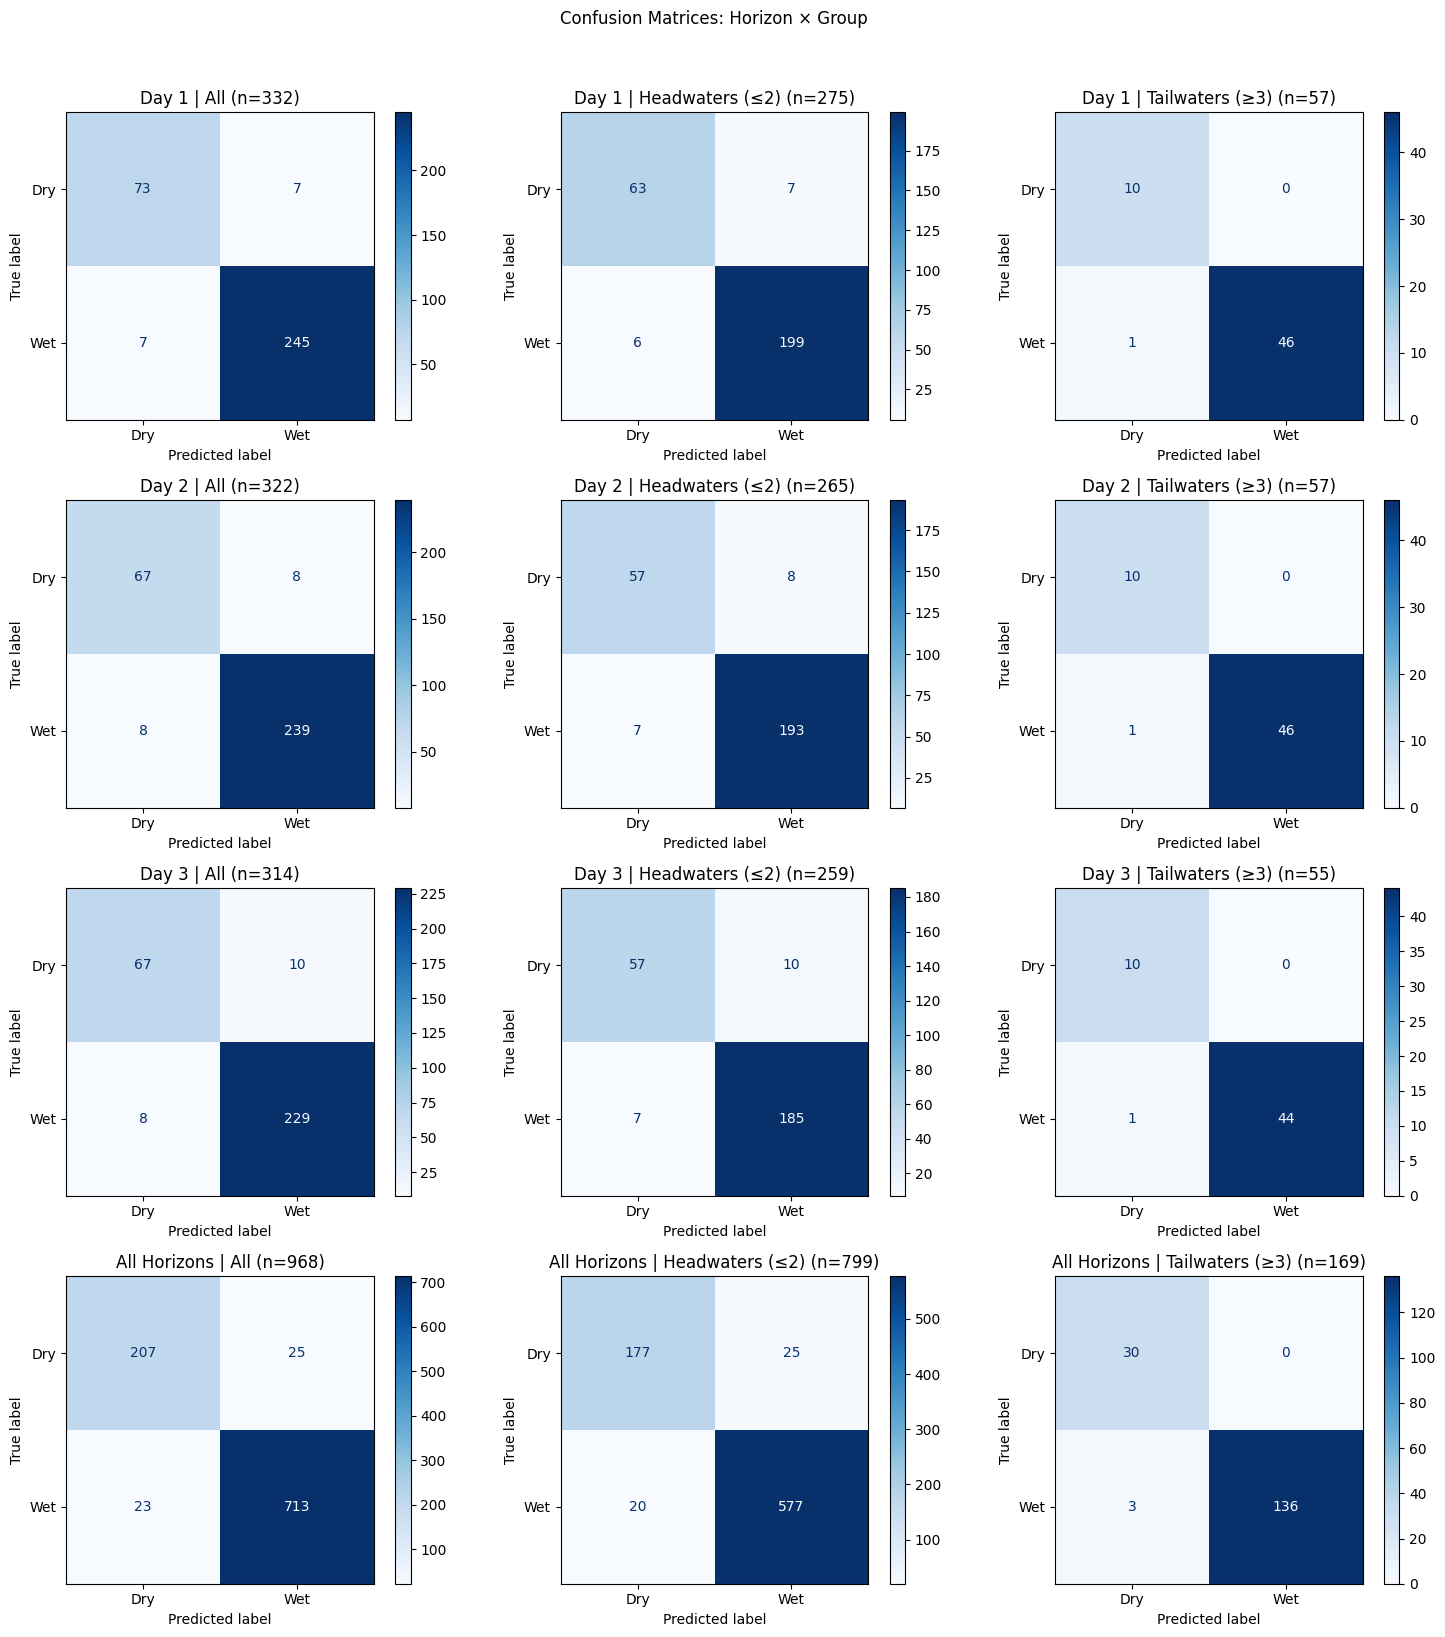

In [6]:
# Confusion matrices: Horizon × Group (All / Headwaters / Tailwaters)
horizon_names = list(horizon_dfs.keys())
group_names = list(group_filters.keys())

fig, axes = plt.subplots(
    len(horizon_names), len(group_names),
    figsize=(5 * len(group_names), 4 * len(horizon_names)),
)

for row_idx, h_name in enumerate(horizon_names):
    h_df = horizon_dfs[h_name]
    for col_idx, (g_name, g_filter) in enumerate(group_filters.items()):
        ax = axes[row_idx][col_idx]
        subset = g_filter(h_df)
        if len(subset) == 0:
            ax.set_visible(False)
            continue
        y_t = subset["true_wetdry"].values
        y_p = subset["pred_wetdry_label"].values
        cm = confusion_matrix(y_t, y_p, labels=[0, 1])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Dry", "Wet"])
        disp.plot(cmap="Blues", values_format="d", ax=ax)
        ax.set_title(f"{h_name} | {g_name} (n={len(subset)})")

plt.suptitle("Confusion Matrices: Horizon × Group", y=1.02)
plt.tight_layout()
plt.show()

## Stream Order Breakdown


Stream Order Breakdown — Day 1
 Order   N  Accuracy  ROC-AUC       F1
     1 166  0.939759 0.983227 0.958333
     2 109  0.972477 0.994775 0.982456
     3  57  0.982456 1.000000 0.989247

Stream Order Breakdown — Day 2
 Order   N  Accuracy  ROC-AUC       F1
     1 162  0.925926 0.974513 0.949153
     2 103  0.970874 0.994361 0.981818
     3  57  0.982456 0.987234 0.989247

Stream Order Breakdown — Day 3
 Order   N  Accuracy  ROC-AUC       F1
     1 158  0.917722 0.975418 0.943723
     2 101  0.960396 0.995397 0.974359
     3  55  0.981818 0.988889 0.988764

Stream Order Breakdown — All Horizons
 Order   N  Accuracy  ROC-AUC       F1
     1 486  0.927984 0.977754 0.950495
     2 313  0.968051 0.995111 0.979675
     3 169  0.982249 0.992326 0.989091


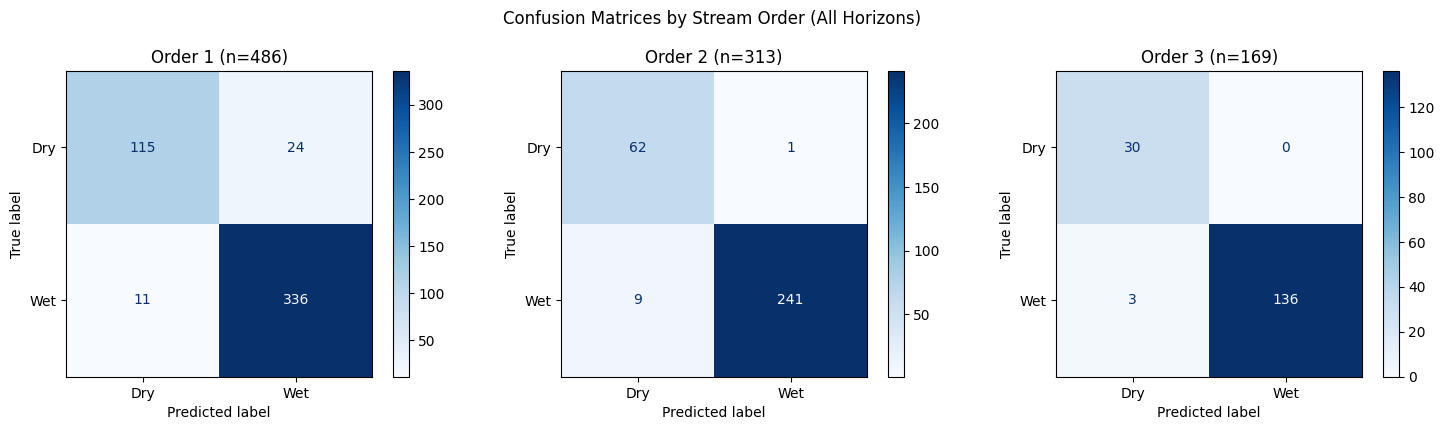

In [7]:
# Per stream order metrics (all horizons) + confusion matrices (aggregated)
order_values = sorted(
    horizon_dfs["All Horizons"]["StreamOrde"].dropna().unique().astype(int)
)

for h_name, h_df in horizon_dfs.items():
    rows = []
    for order in order_values:
        mask = h_df["StreamOrde"] == order
        if mask.sum() == 0:
            continue
        y_t = h_df.loc[mask, "true_wetdry"].values
        y_p = h_df.loc[mask, "pred_wetdry_label"].values
        y_prob = h_df.loc[mask, "pred_wetdry_prob"].values
        acc, roc, f1_val = compute_metrics(y_t, y_p, y_prob)
        rows.append({
            "Order": order, "N": int(mask.sum()),
            "Accuracy": acc, "ROC-AUC": roc, "F1": f1_val,
        })
    print(f"\n{'='*60}")
    print(f"Stream Order Breakdown — {h_name}")
    print("=" * 60)
    print(pd.DataFrame(rows).to_string(index=False))

# Confusion matrices per order (All Horizons)
agg_df = horizon_dfs["All Horizons"]
n_orders = len(order_values)
fig, axes = plt.subplots(1, n_orders, figsize=(5 * n_orders, 4))
if n_orders == 1:
    axes = [axes]

for idx, order in enumerate(order_values):
    ax = axes[idx]
    mask = agg_df["StreamOrde"] == order
    if mask.sum() == 0:
        ax.set_visible(False)
        continue
    y_t = agg_df.loc[mask, "true_wetdry"].values
    y_p = agg_df.loc[mask, "pred_wetdry_label"].values
    cm = confusion_matrix(y_t, y_p, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Dry", "Wet"])
    disp.plot(cmap="Blues", values_format="d", ax=ax)
    ax.set_title(f"Order {order} (n={int(mask.sum())})")

plt.suptitle("Confusion Matrices by Stream Order (All Horizons)", y=1.02)
plt.tight_layout()
plt.show()

## HOBO vs Non-HOBO Site Breakdown (Day 3)

Compare model performance on HOBO sensor sites (discrete wet/dry observations) versus non-HOBO sites (continuous discharge, discretized to wet/dry). HOBO sites are identified as any site with at least one `HoboWetDry0.05` observation in `obs_df`.

HOBO sites in obs_df: 23
Day 3 val — HOBO: 305, Non-HOBO: 9, Total: 314

ALL VALIDATION (n=314)
Accuracy: 0.9427
ROC-AUC:  0.9818
F1 Score: 0.9622
              precision    recall  f1-score   support

         Dry      0.893     0.870     0.882        77
         Wet      0.958     0.966     0.962       237

    accuracy                          0.943       314
   macro avg      0.926     0.918     0.922       314
weighted avg      0.942     0.943     0.942       314


HOBO-ONLY VALIDATION (n=305)
Accuracy: 0.9410
ROC-AUC:  0.9793
F1 Score: 0.9622
              precision    recall  f1-score   support

         Dry      0.879     0.853     0.866        68
         Wet      0.958     0.966     0.962       237

    accuracy                          0.941       305
   macro avg      0.918     0.910     0.914       305
weighted avg      0.940     0.941     0.941       305


NON-HOBO (DISCRETIZED) VALIDATION (n=9)
Accuracy: 1.0000
ROC-AUC:  nan
F1 Score: 0.0000
              precision    re

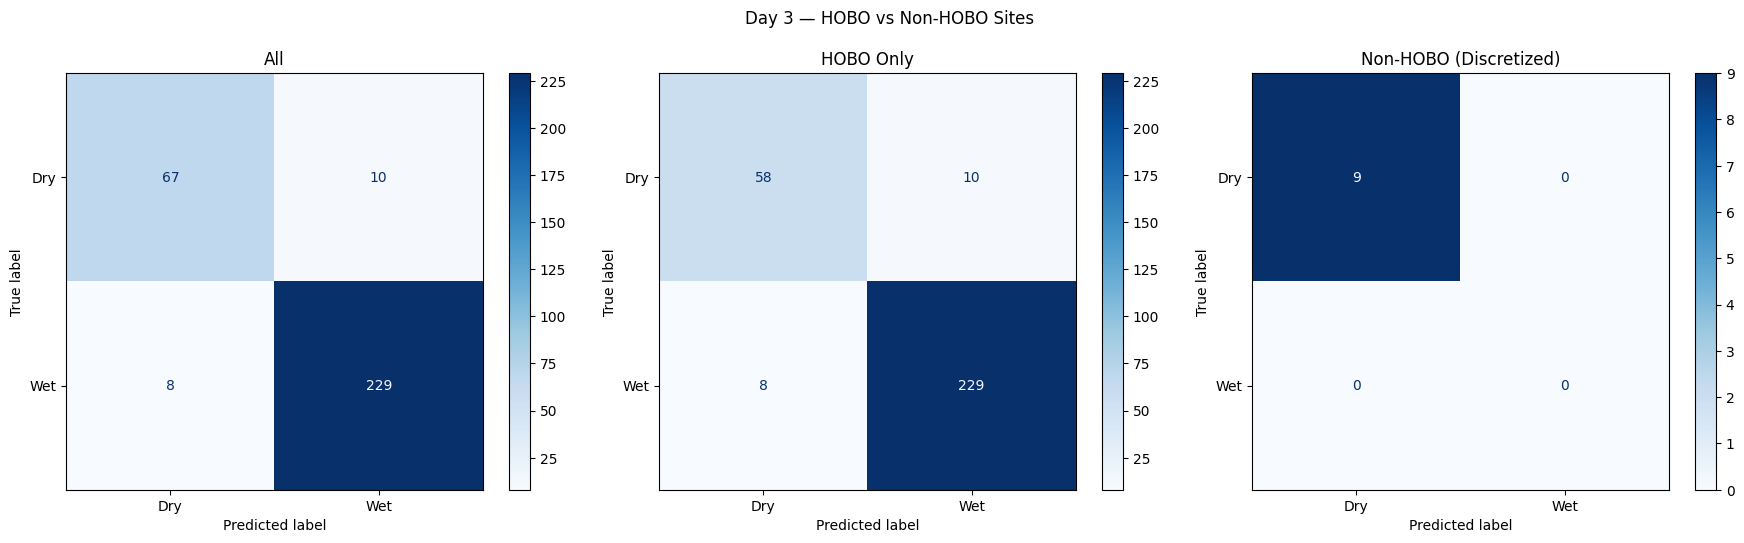

In [8]:
# Identify HOBO site IDs from obs_df
hobo_site_ids = set(
    obs_df[obs_df['HoboWetDry0.05'].notna()]['NHDPlusID'].astype(str)
)
print(f"HOBO sites in obs_df: {len(hobo_site_ids)}")

# Use Day 3 validation data
day3_val = horizon_dfs["Day 3"].copy()
day3_val["site_id_str"] = day3_val["site_id"].astype(str)
day3_val["is_hobo"] = day3_val["site_id_str"].isin(hobo_site_ids)

hobo_mask = day3_val["is_hobo"]
disc_mask = ~day3_val["is_hobo"]

print(f"Day 3 val — HOBO: {hobo_mask.sum()}, Non-HOBO: {disc_mask.sum()}, Total: {len(day3_val)}")

# Metrics per subset
def print_subset_metrics(name, subset):
    y_t = subset["true_wetdry"].values
    y_p = subset["pred_wetdry_label"].values
    y_prob = subset["pred_wetdry_prob"].values
    acc, roc, f1_val = compute_metrics(y_t, y_p, y_prob)
    print(f"\n{'='*50}")
    print(f"{name} (n={len(subset)})")
    print(f"{'='*50}")
    print(f"Accuracy: {acc:.4f}")
    print(f"ROC-AUC:  {roc:.4f}")
    print(f"F1 Score: {f1_val:.4f}")
    print(classification_report(y_t, y_p, labels=[0, 1],
                                target_names=['Dry', 'Wet'], digits=3, zero_division=0))
    return acc, roc, f1_val

acc_all, roc_all, f1_all = print_subset_metrics("ALL VALIDATION", day3_val)
acc_hobo, roc_hobo, f1_hobo = print_subset_metrics("HOBO-ONLY VALIDATION", day3_val[hobo_mask])
acc_disc, roc_disc, f1_disc = print_subset_metrics("NON-HOBO (DISCRETIZED) VALIDATION", day3_val[disc_mask])

# Summary table
results_df = pd.DataFrame({
    'Validation Set': ['All', 'HOBO Only', 'Non-HOBO (Discretized)'],
    'N': [len(day3_val), int(hobo_mask.sum()), int(disc_mask.sum())],
    'Accuracy': [acc_all, acc_hobo, acc_disc],
    'ROC-AUC': [roc_all, roc_hobo, roc_disc],
    'F1': [f1_all, f1_hobo, f1_disc]
})
print(f"\n{'='*50}")
print("Summary")
print('='*50)
print(results_df.to_string(index=False))

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, subset) in zip(axes, [
    ('All', day3_val),
    ('HOBO Only', day3_val[hobo_mask]),
    ('Non-HOBO (Discretized)', day3_val[disc_mask])
]):
    y_t = subset["true_wetdry"].values
    y_p = subset["pred_wetdry_label"].values
    cm = confusion_matrix(y_t, y_p, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dry', 'Wet'])
    disp.plot(cmap='Blues', values_format='d', ax=ax)
    ax.set_title(name)

plt.suptitle('Day 3 — HOBO vs Non-HOBO Sites', y=1.02)
plt.tight_layout()
plt.show()

## Estimating Annual Dry-Day Counts with Uncertainty (Day 3)

**Canonical copula experiment: the q65-trained RGCN scored on the q65
validation period** (matching `benchmarks/flagship_copula_all.py`, q65
section). For each of the top 8 HOBO reaches by validation label count,
estimate the expected number of dry days in a 365-day period with a 95%
interval. Each Monte Carlo realization simulates a 365-day binary dry/wet
sequence from the model's per-day predicted probabilities, accounting for the
temporal autocorrelation that makes dry spells cluster.

We use a **Gaussian copula with AR(1) correlation**:

1. Estimate the lag-1 autocorrelation ρ of the site's binary wet/dry status
   from the **raw daily HOBO record on the split's training dates**, using
   **consecutive-calendar-day pairs only**. (An earlier revision estimated ρ
   on the stride-3 window grid, which actually measures lag-3 correlation.)
2. For each simulation, draw a length-365 stationary AR(1) Gaussian path
   `z_t = ρ·z_{t-1} + ε_t` with innovation variance `1-ρ²` so marginals are N(0,1).
3. Transform to uniforms via `u_t = Φ(z_t)` — marginally Uniform(0,1) but
   temporally correlated.
4. Bootstrap 365 `p_dry` values from the site's **stride-1 (daily) Day-3
   validation predictions**, and mark day t as dry iff `u_t < p_dry_t`.

The observed annual dry-day count is estimated as
`(1 − validation wet fraction) × 365` and checked against the MC interval.

Caveat: the q65 validation period is late-season only (HOBO labels
Sep 11 – Oct 29, 2020), so the bootstrapped "typical year" is dry-biased.

Top-8 HOBO reaches by val label count:
site_id
55000900167704    52
55000900097170    48
55000900237668    48
55000900202948    43
55000900030173    43
55000900029021    43
55000900201811    43
55000900131558    42



       Site ID  Rho (AR1)  Rho pairs  N val  True Dry Days/Yr  Mean Pred Dry Days/Yr  95% CI Low  95% CI High  In CI
55000900097170      1.000         81     48             349.8                  209.9         0.0        365.0   True
55000900237668      0.927         64     48             319.4                  326.4       293.0        350.0   True
55000900167704      0.000         84     52              77.2                   66.1        52.0         80.0   True
55000900029021      0.000         84     43              25.5                   42.8        31.0         55.0  False
55000900202948      0.000         77     43               0.0                    6.5         2.0         12.0  False
55000900030173      0.000         77     43               0.0                    8.2         3.0         14.0  False
55000900201811      0.000         84     43               0.0                    6.2         2.0         11.0  False
55000900131558      0.000         79     42               0.0  

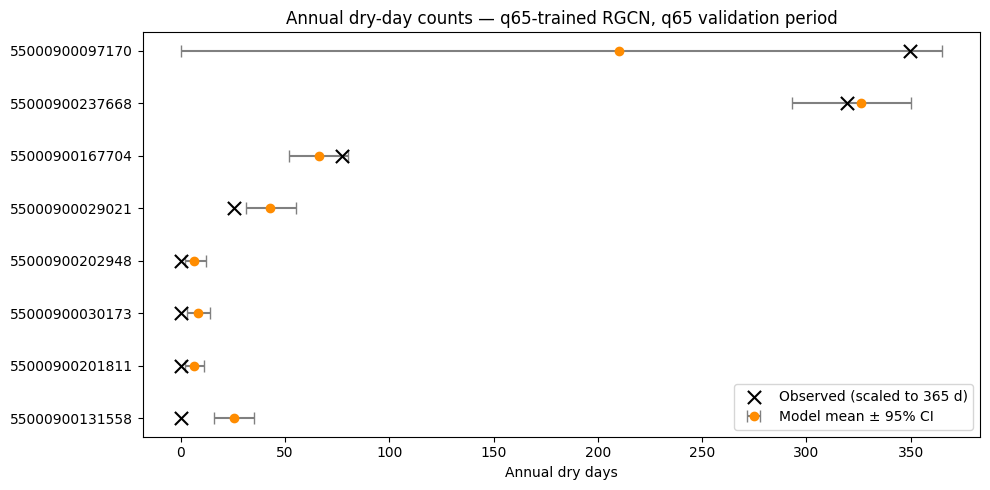

In [9]:
# Correlated Monte Carlo via Gaussian copula with AR(1) temporal correlation
from scipy.stats import norm

N_SIMS = 10000
HORIZON_DAYS = 365
Q65_CUTOFF = pd.Timestamp("2020-09-10")
rng = np.random.default_rng(42)

# Raw daily HOBO series (site, date) -> wet/dry, for rho estimation
hobo_daily = (obs_df.assign(Date=pd.to_datetime(obs_df["Date"]))
              .groupby(["NHDPlusID", "Date"])["HoboWetDry0.05"].mean()
              .round().dropna().rename("wet").reset_index())
hobo_daily["NHDPlusID"] = hobo_daily["NHDPlusID"].astype("int64")
hobo_ids = set(hobo_daily["NHDPlusID"])

# Stride-1 Day-3 predictions over the q65 val period, HOBO reaches only
s1 = pd.read_csv(STRIDE1_DAY3_PATH, parse_dates=["date"])
s1 = s1[s1["has_true_label"] & (s1["date"] > Q65_CUTOFF)].copy()
s1["site_id"] = s1["site_id"].astype("int64")
s1 = s1[s1["site_id"].isin(hobo_ids)]

label_counts = s1.groupby("site_id").size().sort_values(ascending=False)
top8_sites = label_counts.head(8).index.tolist()
print("Top-8 HOBO reaches by val label count:")
print(label_counts.head(8).to_string())


def estimate_rho(site_id):
    """Lag-1 autocorrelation from consecutive-day pairs of the raw daily HOBO
    series on q65 TRAINING dates (<= cutoff)."""
    s = hobo_daily[(hobo_daily["NHDPlusID"] == site_id)
                   & (hobo_daily["Date"] <= Q65_CUTOFF)].sort_values("Date")
    v = s["wet"].to_numpy()
    consec = s["Date"].diff().dt.days.to_numpy()[1:] == 1
    a, b = v[:-1][consec], v[1:][consec]
    if len(a) < 3 or a.std() == 0 or b.std() == 0:
        return 0.0, int(len(a))
    return float(np.corrcoef(a, b)[0, 1]), int(len(a))


def simulate_ar1_gaussian(n_sims, n_days, rho, rng):
    """Stationary AR(1) Gaussian paths: z_t = rho*z_{t-1} + eps, eps ~ N(0, 1-rho^2)."""
    innov = rng.standard_normal((n_sims, n_days)) * np.sqrt(max(1 - rho**2, 0.0))
    z = np.empty((n_sims, n_days))
    z[:, 0] = rng.standard_normal(n_sims)
    for t in range(1, n_days):
        z[:, t] = rho * z[:, t - 1] + innov[:, t]
    return z


rows = []
for site in top8_sites:
    site_val = s1[s1["site_id"] == site]
    p_dry = 1.0 - site_val["pred_wetdry_prob"].values
    rho, n_pairs = estimate_rho(site)

    # Correlated uniforms via Gaussian copula
    z = simulate_ar1_gaussian(N_SIMS, HORIZON_DAYS, rho, rng)
    u = norm.cdf(z)

    # Bootstrap p_dry values (independent of z — copula only injects temporal correlation)
    sampled_p_dry = rng.choice(p_dry, size=(N_SIMS, HORIZON_DAYS), replace=True)
    sim_dry_counts = (u < sampled_p_dry).sum(axis=1)

    mean_pred = sim_dry_counts.mean()
    lo, hi = np.percentile(sim_dry_counts, [2.5, 97.5])
    true_wet_frac = site_val["true_wetdry"].round().mean()
    true_dry_annual = (1.0 - true_wet_frac) * HORIZON_DAYS
    in_ci = bool(lo <= true_dry_annual <= hi)

    rows.append({
        "Site ID": site,
        "Rho (AR1)": round(rho, 3),
        "Rho pairs": n_pairs,
        "N val": len(site_val),
        "True Dry Days/Yr": round(true_dry_annual, 1),
        "Mean Pred Dry Days/Yr": round(mean_pred, 1),
        "95% CI Low": round(float(lo), 1),
        "95% CI High": round(float(hi), 1),
        "In CI": in_ci,
    })

mc_corr_df = pd.DataFrame(rows).sort_values("True Dry Days/Yr", ascending=False)
print()
print(mc_corr_df.to_string(index=False))

coverage = mc_corr_df["In CI"].mean()
print(f"\nCoverage: {mc_corr_df['In CI'].sum()}/{len(mc_corr_df)} sites "
      f"({coverage:.0%}) fall within their 95% CI.")
print("Covered sites are the intermittent reaches; the misses are dominated by "
      "perennial reaches\n(0 observed dry days) whose intervals exclude zero — "
      "a probability-calibration limitation.")

fig, ax = plt.subplots(figsize=(10, 5))
y_pos = np.arange(len(mc_corr_df))
ax.errorbar(
    mc_corr_df["Mean Pred Dry Days/Yr"], y_pos,
    xerr=[mc_corr_df["Mean Pred Dry Days/Yr"] - mc_corr_df["95% CI Low"],
          mc_corr_df["95% CI High"] - mc_corr_df["Mean Pred Dry Days/Yr"]],
    fmt="o", color="darkorange", ecolor="gray", capsize=4,
    label="Model mean ± 95% CI")
ax.scatter(mc_corr_df["True Dry Days/Yr"], y_pos, marker="x", s=90,
           color="black", zorder=5, label="Observed (scaled to 365 d)")
ax.set_yticks(y_pos)
ax.set_yticklabels(mc_corr_df["Site ID"].astype(str))
ax.set_xlabel("Annual dry days")
ax.set_title("Annual dry-day counts — q65-trained RGCN, q65 validation period")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Map: per-site CI coverage

The same Day-3 result table, shown spatially. Each tested HOBO site is placed at its NHDPlus-HR flowline centroid over the H.J. Andrews stream network and an elevation-tinted hillshade. A green **✓** means the observed annual dry-day count fell inside the model's 95% CI; a red **✗** means it fell outside. Stream geometry and the hillshade are fetched once from the USGS/Esri ArcGIS REST services and cached under `../data/huggingface/map_cache/`.

3/8 sites had observed dry-day counts inside the model's 95% CI.


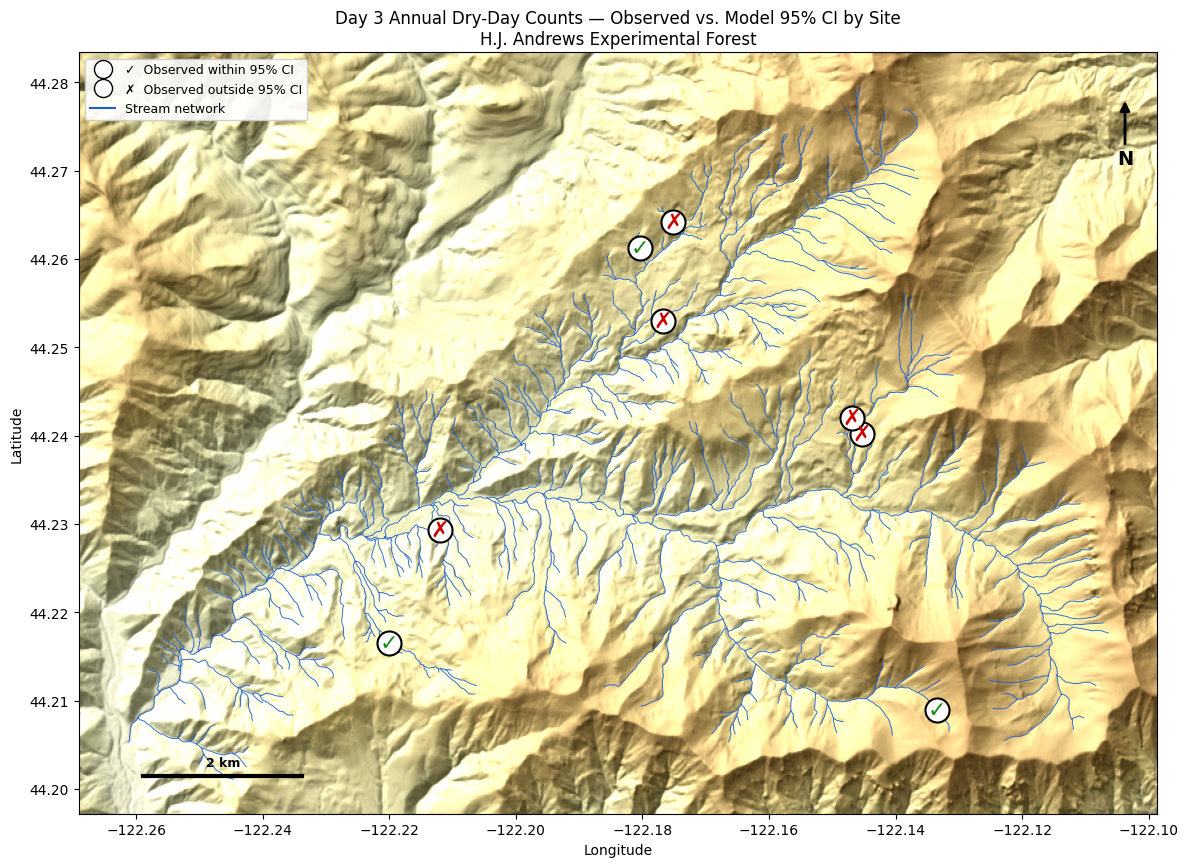

In [10]:
# Map of tested sites: green ✓ if the observed annual dry-day count fell inside the
# model's 95% CI, red ✗ otherwise. Stream network + elevation-tinted hillshade are
# pulled once from USGS/Esri ArcGIS REST services and cached locally for fast re-runs.
import os, io, json, requests
from matplotlib.lines import Line2D

CACHE_DIR = "../data/huggingface/map_cache"
GEOM_CACHE = os.path.join(CACHE_DIR, "hja_flowline_geoms_4326.json")
HILLSHADE_CACHE = os.path.join(CACHE_DIR, "hja_tinted_hillshade.png")
os.makedirs(CACHE_DIR, exist_ok=True)

FLOWLINE_LAYER = "https://hydro.nationalmap.gov/arcgis/rest/services/NHDPlus_HR/MapServer/3/query"
ELEV_IMG = "https://elevation.nationalmap.gov/arcgis/rest/services/3DEPElevation/ImageServer/exportImage"


def load_flowline_geoms(nhd_ids):
    """Fetch NHDPlus-HR flowline geometries (lon/lat paths) for the given IDs, cached to disk."""
    if os.path.exists(GEOM_CACHE):
        return {int(k): v for k, v in json.load(open(GEOM_CACHE)).items()}
    geoms = {}
    ids = [int(i) for i in nhd_ids]
    for i in range(0, len(ids), 120):
        chunk = ids[i:i + 120]
        params = dict(where="NHDPlusID IN (" + ",".join(map(str, chunk)) + ")",
                      outFields="NHDPlusID", returnGeometry="true", f="json", outSR="4326")
        feats = requests.get(FLOWLINE_LAYER, params=params, timeout=90).json().get("features", [])
        for ft in feats:
            geoms[int(ft["attributes"]["nhdplusid"])] = ft["geometry"]["paths"]
    json.dump(geoms, open(GEOM_CACHE, "w"))
    return geoms


def load_hillshade(bbox):
    """Elevation-tinted hillshade PNG for the bounding box (xmin,ymin,xmax,ymax), cached to disk."""
    if os.path.exists(HILLSHADE_CACHE):
        return plt.imread(HILLSHADE_CACHE)
    xmin, ymin, xmax, ymax = bbox
    w = 1200
    h = int(w * (ymax - ymin) / (xmax - xmin))
    params = dict(bbox=f"{xmin},{ymin},{xmax},{ymax}", bboxSR="4326", imageSR="4326",
                  size=f"{w},{h}", format="png", f="image",
                  renderingRule=json.dumps({"rasterFunction": "Hillshade Elevation Tinted"}))
    content = requests.get(ELEV_IMG, params=params, timeout=120).content
    open(HILLSHADE_CACHE, "wb").write(content)
    return plt.imread(io.BytesIO(content))


# --- geometry ---
network_ids = day_3_df["site_id"].unique()
geoms = load_flowline_geoms(network_ids)

all_pts = np.concatenate([np.array(p) for paths in geoms.values() for p in paths])
xmin, ymin = all_pts.min(axis=0)
xmax, ymax = all_pts.max(axis=0)
padx, pady = (xmax - xmin) * 0.05, (ymax - ymin) * 0.05
bbox = (xmin - padx, ymin - pady, xmax + padx, ymax + pady)
midlat = (bbox[1] + bbox[3]) / 2
hillshade = load_hillshade(bbox)


def site_centroid(nid):
    pts = np.concatenate([np.array(p) for p in geoms[int(nid)]])
    return pts[:, 0].mean(), pts[:, 1].mean()


# --- figure ---
fig, ax = plt.subplots(figsize=(12, 9))
ax.imshow(hillshade, extent=[bbox[0], bbox[2], bbox[1], bbox[3]], zorder=0, aspect="auto")
for paths in geoms.values():
    for p in paths:
        a = np.array(p)
        ax.plot(a[:, 0], a[:, 1], color="#1f5fd0", lw=0.7, alpha=0.9, zorder=2)

for _, r in mc_corr_df.iterrows():
    if int(r["Site ID"]) not in geoms:
        continue
    lon, lat = site_centroid(r["Site ID"])
    ok = bool(r["In CI"])
    ax.scatter(lon, lat, s=300, marker="o", facecolor="white",
               edgecolor="black", linewidth=1.5, zorder=5)
    ax.text(lon, lat, "✓" if ok else "✗", ha="center", va="center",
            fontsize=16, fontweight="bold",
            color="#1a8a1a" if ok else "#cc0000", zorder=6)

ax.set_xlim(bbox[0], bbox[2])
ax.set_ylim(bbox[1], bbox[3])
ax.set_aspect(1 / np.cos(np.deg2rad(midlat)))
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Day 3 Annual Dry-Day Counts — Observed vs. Model 95% CI by Site\n"
             "H.J. Andrews Experimental Forest", fontsize=12)

legend_handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor="white",
           markeredgecolor="black", markersize=13, label="✓  Observed within 95% CI"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="white",
           markeredgecolor="black", markersize=13, label="✗  Observed outside 95% CI"),
    Line2D([0], [0], color="#1f5fd0", lw=1.5, label="Stream network"),
]
ax.legend(handles=legend_handles, loc="upper left", fontsize=9, framealpha=0.9)

# north arrow
ax.annotate("N", xy=(0.97, 0.94), xytext=(0.97, 0.86), xycoords="axes fraction",
            ha="center", va="center", fontsize=14, fontweight="bold",
            arrowprops=dict(arrowstyle="-|>", color="black", lw=2))

# 2 km scale bar
km = 2.0
dlon = km / (111.320 * np.cos(np.deg2rad(midlat)))
x0 = bbox[0] + (bbox[2] - bbox[0]) * 0.06
y0 = bbox[1] + (bbox[3] - bbox[1]) * 0.05
ax.plot([x0, x0 + dlon], [y0, y0], color="black", lw=3, zorder=7)
ax.text(x0 + dlon / 2, y0 + (bbox[3] - bbox[1]) * 0.012, f"{km:.0f} km",
        ha="center", fontsize=9, fontweight="bold")

n_ok = int(mc_corr_df["In CI"].sum())
print(f"{n_ok}/{len(mc_corr_df)} sites had observed dry-day counts inside the model's 95% CI.")
plt.tight_layout()
plt.show()
